#### Importing Python Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
confusion_matrix,classification_report,ConfusionMatrixDisplay,
accuracy_score,precision_score,recall_score,f1_score,
roc_curve,auc
)

#### Loading the Testing Sets

In [2]:
df = pd.read_csv("../../Dataset/Testing-Dataset.csv",keep_default_na=False)
df.head()

,Text,Target
0,yes black red fav color really wanted color de...,0
1,buy open house weekend ampm best value bedroom...,1
2,fran greet air thats okay hahahaha thanks,1
3,omg thats awesome goood luck meet caaute calga...,1
4,hahahhaha good point,1


#### Loading the Model

In [3]:
model = joblib.load("../../Models/lor-count.joblib")
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('cv', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


#### Splitting the Dataset

In [4]:
x_test = df['Text']
y_test = df['Target']

#### Predicting the Values

In [5]:
y_pred = model.predict(x_test)
y_pred

array([1, 1, 1, ..., 0, 0, 1], shape=(320000,))

In [6]:
y_proba = model.predict_proba(x_test)[:,1]
y_proba

array([0.85051507, 0.88697921, 0.95531543, ..., 0.12918316, 0.09918836,
       0.80994286], shape=(320000,))

In [7]:
results_df = pd.DataFrame({
    "y_test": y_test,
    "y_pred": y_pred
})

results_df.sample(10)

,y_test,y_pred
284176,0,0
76606,1,0
316173,0,0
188066,0,0
284172,0,1
265671,0,0
161368,0,0
17163,0,0
10953,0,0
80499,1,1


#### Classification Metrics

In [8]:
print("Classification Report :")
print(classification_report(y_test,y_pred))

Classification Report :
              precision    recall  f1-score   support

           0       0.80      0.74      0.77    160000
           1       0.76      0.82      0.79    160000

    accuracy                           0.78    320000
   macro avg       0.78      0.78      0.78    320000
weighted avg       0.78      0.78      0.78    320000



In [9]:
print("Classification Metrics :")
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Score": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]
})

metrics_df

Classification Metrics :


,Metric,Score
0,Accuracy,0.778750
1,Precision,0.757744
2,Recall,0.819500
3,F1 Score,0.787413


#### Computing and Plotting the Confusion Matrix

In [10]:
cm = confusion_matrix(y_test,y_pred)
print("Confusion Matrix :")
print(cm)

Confusion Matrix :
[[118080  41920]
 [ 28880 131120]]


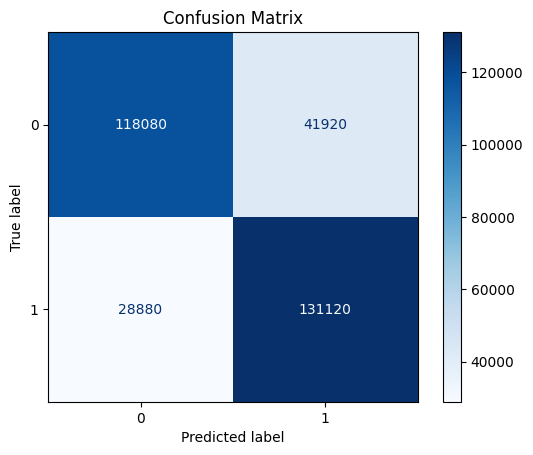

In [11]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

#### Plotting the ROC-AUC Curve

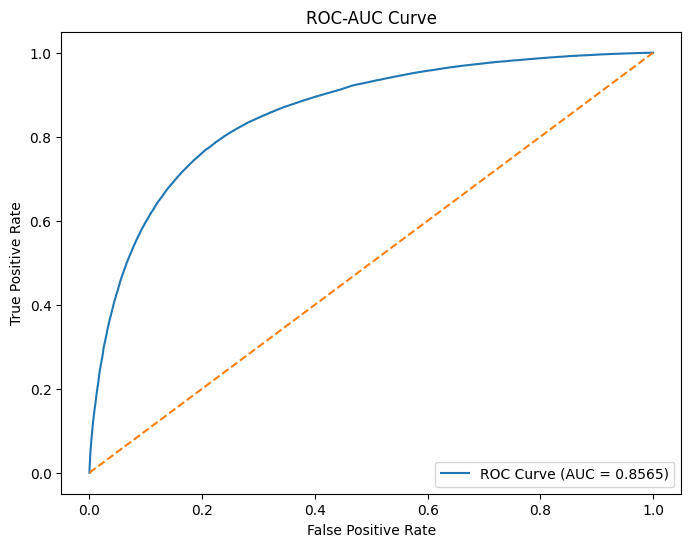

In [12]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")
plt.legend(loc="lower right")
plt.show()